## Satellite image classification

Configurable parameters in the notebook

#### 1. Config.IMAGE_SIZE

- Significance: controls the resolution of every image before feature extraction.
- Increase: preserves more detail, can improve feature quality, but increases compute time and memory.
- Decrease: makes processing faster and features smaller, but may lose fine texture and edge detail.

#### 2. Config.MAX_IMAGES_PER_CLASS

- Significance: limits how many images are loaded for each class.
- Increase: more training data → typically better model generalization, but slower loading/training.
- Decrease: faster experiments, but models may underfit and accuracy can drop.

#### 3. Config.TEST_SIZE

- Significance: fraction of data reserved for evaluation.
- Increase: more reliable test evaluation, but less training data.
- Decrease: more training data, but evaluation becomes less robust and may overestimate performance.

#### 4. Config.RANDOM_STATE

- Significance: seed for reproducibility of splits and model behavior.
- Increase/decrease: does not change model behavior in expectation, only changes which exact samples are assigned to train/test. It is for reproducibility, not performance tuning.
Texture and gradient feature parameters

#### 5. Config.LBP_POINTS

- Used by Local Binary Pattern.
- Significance: number of neighbors around each pixel.
- Increase: captures more angular detail, gives richer texture description, but longer histogram and more sensitivity to noise.
- Decrease: simpler texture description, less detail, faster and often more robust for noisy images.

#### 6. Config.LBP_RADIUS

- Used by Local Binary Pattern.
- Significance: distance from center pixel to neighbors.
- Increase: captures broader texture patterns over larger neighborhoods.
- Decrease: captures only very local micro-texture.

#### 7. Config.LBP_RADII

- Used by multi-scale LBP extraction.
- Significance: defines multiple radii for texture capture at different scales.
- Increase count or values: more multi-scale texture detail, larger feature vector, more compute.
- Decrease: simpler and more compact texture representation.

#### 8. Config.HOG_ORIENTATIONS

- Used by HOG.
- Significance: number of orientation bins for gradient directions.
- Increase: finer edge direction resolution, more discriminative gradient features, but larger feature vector.
- Decrease: coarser orientation encoding, less detail but smaller feature size.

#### 9. Config.HOG_PIXELS_PER_CELL

- Used by HOG.
- Significance: size of the basic spatial cell.
- Increase: each cell covers more pixels → coarser spatial resolution, fewer features, smoother gradients.
- Decrease: finer spatial resolution, more features, potentially more sensitive to noise.

#### 10. Config.HOG_CELLS_PER_BLOCK

- Used by HOG.
- Significance: block normalization region.
- Increase: more context in each normalized block, larger feature vector, more stable descriptor.
- Decrease: smaller normalization area, less context, potentially less stable but smaller descriptor.
- Co-occurrence and directional texture

#### 11. Config.GLCM_DISTANCES

- Used by multi-scale GLCM.
- Significance: distances between paired pixels for texture co-occurrence.
- Increase values / more distances: captures texture at larger scales and more scales, but longer feature vector and more compute.
- Decrease: focuses on very local relationships.

#### 12. Config.GLCM_ANGLES

- Used by GLCM.
- Significance: directions in which pixel pairs are compared.
- Increase angles: captures more directional texture variation, more robust to orientation.
- Decrease angles: faster and lower-dimensional, but may miss directional differences.
Spatial, line, and frequency parameters

#### 13. Config.SPATIAL_GRID

- Used in extract_spatial_features.
- Significance: divides the image into patches and computes local mean/std.
- Increase grid size: better capture of spatial structure, but more features and possible overfitting.
- Decrease grid size: more global statistics, fewer features, less spatial detail.

#### 14. Config.LINE_ORIENTATION_BINS

- Used in extract_line_features.
- Significance: number of bins for the line angle histogram.
- Increase: more precise orientation distribution of lines, but sparse representation.
- Decrease: coarser orientation summary, simpler and more stable.

#### 15. Config.DFT_BANDS

- Used in extract_frequency_features.
- Significance: number of radial frequency bands in Fourier magnitude.
- Increase: finer frequency resolution, more features, more sensitivity to texture frequency.
- Decrease: coarser frequency summary, smaller feature vector.
- Additional implicit tuning knobs in feature code
These are not in Config but affect feature behavior:

#### Extra
- Color histogram bins: currently 32 per channel. Increase → finer color detail, larger vector.
- Sobel kernel ksize=3: larger kernels smooth more and detect broader gradients; smaller kernels capture finer edges.
- Canny thresholds 100, 200: lower thresholds detect more edges/noise; higher thresholds keep only strong edges.
- Hough line thresholds: control line detection sensitivity and minimum line length.

- Practical guidance:
> Increase parameters when you want more descriptive power and have enough compute/data.
> Decrease parameters when the model is too slow, overfits, or the dataset is noisy.

- The main tradeoff is always:
> more features/detail → better potential discrimination but higher cost and risk of overfitting
less detail → faster, more stable, but potentially less accurate

In [1]:
import os

import cv2

import numpy as np

import matplotlib.pyplot as plt

import time

import logging

import warnings

from tqdm import tqdm


from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern,
    hog
)


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


warnings.filterwarnings("ignore")



class Config:
    """
    Centralized configuration class.

    Storing parameters in one place makes the code:
        - Cleaner
        - Easier to modify
        - More maintainable
    """


    DATASET_PATH = "EuroSAT"


    IMAGE_SIZE = (128, 128)


    URBAN_CLASSES = [
        "Residential",
        "Industrial",
        "Highway"
    ]

    NATURAL_CLASSES = [
        "Forest",
        "River",
        "Pasture",
        "SeaLake",
        "AnnualCrop",
        "PermanentCrop",
        "HerbaceousVegetation"
    ]


    MAX_IMAGES_PER_CLASS = 100 # TODO: Increase for better accuuracy


    TEST_SIZE = 0.2
    RANDOM_STATE = 42


    LBP_RADIUS = 2
    LBP_POINTS = 16
    LBP_RADII = [1, 2, 4]


    HOG_ORIENTATIONS = 9
    HOG_PIXELS_PER_CELL = (8, 8)
    HOG_CELLS_PER_BLOCK = (2, 2)


    GLCM_DISTANCES = [1, 2, 4]
    GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    SPATIAL_GRID = (2, 2)
    LINE_ORIENTATION_BINS = 8
    DFT_BANDS = 4


    LOG_LEVEL = logging.INFO

In [2]:
logging.basicConfig(
    level=Config.LOG_LEVEL,
    format="%(asctime)s [%(levelname)s] %(message)s"
)

logger = logging.getLogger(__name__)



def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        logger.info(f"{func.__name__} completed in {end - start:.2f} sec")
        return result
    return wrapper



def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, Config.IMAGE_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return image, gray





In [ ]:
import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog

def extract_pixel_features(image):
    """
    Extracts global raw pixel statistics and normalized color histograms.

    Importance of Feature:
        Captures the foundational color distribution and brightness profile of an 
        image without capturing spatial geometry. It acts as a baseline visual signature.

    How It Works:
        1. Computes the global mean and standard deviation for each color channel.
        2. Generates a 32-bin intensity histogram for each channel to capture the 
           frequency distribution of pixel intensities.
        3. Normalizes the histograms to ensure scale invariance and flattens them.

    Why Useful:
        Extremely computationally light and invariant to image rotation. It helps the 
        model quickly differentiate classes that have distinct color profiles or lighting setups.

    Example:
        Differentiating heavily built-up commercial centers (dominated by gray/white concrete 
        and asphalt pixel values) from deep dense forests or crop fields (dominated by high 
        mean values in the green and dark infrared-proximate channels).
    """
    mean_rgb = np.mean(image, axis=(0, 1))
    std_rgb = np.std(image, axis=(0, 1))

    hist_features = []
    for channel in range(3):
        hist = cv2.calcHist([image], [channel], None, [32], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)

    return np.concatenate([mean_rgb, std_rgb, hist_features])


def extract_color_ratio_features(image):
    """
    Extracts specialized vegetation indices and color ratio statistics.

    Importance of Feature:
        Isolates specific target material properties (like chlorophyll or pigmentation) 
        by mathematically combining color channels to cancel out uniform lighting variations and shadows.

    How It Works:
        Isolates individual color channels to calculate specialized relative indexes:
        - NDVI-Variant: Normalized Difference Vegetation Index variant using visible green/red.
        - ExG (Excess Green): Highlights vibrant green regions.
        - ExR (Excess Red): Highlights vibrant red regions.
        - ExGR (Excess Green minus Excess Red): Maximizes contrast between plant matter and soil.
        The function returns the mean and variance (std) of these transformed feature maps.

    Why Useful:
        Crucial for agricultural ML, forestry management, or object segmentation where 
        ambient lighting fluctuates wildly (e.g., overcast vs. sunny days), but the true 
        underlying color ratio of the asset remains unchanged.

    Example:
        Isolating crop plots, parks, and pastures from concrete residential zones. While 
        metallic roofs alter absolute brightness across frames, the ExG and NDVI ratios 
        for active rural vegetation remain strongly decoupled from inert urban surfaces.

    """
    image = image.astype("float32")
    R = image[..., 0]
    G = image[..., 1]
    B = image[..., 2]

    ndvi = (G - R) / (G + R + 1e-6)
    exg = 2.0 * G - R - B
    exr = 1.4 * R - G
    exgr = G - R

    return np.array([
        np.mean(ndvi),
        np.std(ndvi),
        np.mean(exg),
        np.std(exg),
        np.mean(exr),
        np.std(exr),
        np.mean(exgr),
        np.std(exgr)
    ])


def extract_multiscale_glcm_features(gray):
    """
    Extracts texture descriptors using Gray-Level Co-occurrence Matrices (GLCM).

    Importance of Feature:
        Captures structural spatial relationships by analyzing how often pairs of pixels 
        with specific intensities occur together at specified pixel distances and angles.

    How It Works:
        Iterates through multiple pixel distances to build a spatial dependency matrix. 
        From this matrix, it derives four core structural metrics:
        - Contrast: Measures local intensity variations.
        - Homogeneity: Measures the closeness of the distribution of elements to the GLCM diagonal.
        - Energy: Measures textural uniformity (orderliness).
        - Correlation: Measures how linearly correlated a pixel is to its neighbor.

    Why Useful:
        Excellent for identifying repeating patterns, roughness, or material composition 
        where standard color filters fail because the global color profile is identical.

    Example:
        Distinguishing an unpaved rural field from a residential roofs, 
        even if both present identical global gray hues. The sandpaper-like micro-roughness of soil 
        creates low homogeneity and high local contrast compared to uniform industrial materials.
    """
    properties = ['contrast', 'homogeneity', 'energy', 'correlation']
    features = []

    for distance in Config.GLCM_DISTANCES:
        glcm = graycomatrix(
            gray,
            distances=[distance],
            angles=Config.GLCM_ANGLES,
            levels=256,
            symmetric=True,
            normed=True
        )
        for prop in properties:
            values = graycoprops(glcm, prop)
            features.append(values.mean())

    return np.array(features)


def extract_multiscale_lbp_features(gray):
    """
    Extracts Local Binary Pattern (LBP) histograms across multiple spatial scales.

    Importance of Feature:
        Acts as a powerful, highly robust descriptor for micro-textures and local structures. 
        It is completely invariant to monotonic changes in grayscale illumination.

    How It Works:
        1. Compares each pixel with its surrounding neighbors at a specified circle radius.
        2. Sets neighboring pixels to 1 if they are brighter than the center, or 0 if darker.
        3. Converts this binary ring into a decimal number to label the center pixel.
        4. Collects these labels across the image into a normalized histogram.

    Why Useful:
        Maintains structural accuracy even if the image experiences severe shadowing, 
        vignetting, or shifts in contrast, making it perfect for facial recognition or fine-grain classification.

    Example:
        Identifying low-density residential suburbs vs. raw agricultural land. The uniform, 
        alternating micro-textures of roof-to-lawn transitions produce distinct LBP signatures 
        that remain stable across varying atmospheric conditions.
    """
    features = []
    for radius in Config.LBP_RADII:
        lbp = local_binary_pattern(gray, Config.LBP_POINTS, radius, method="uniform")
        bins = Config.LBP_POINTS + 2
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, bins + 1), range=(0, bins))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        features.extend(hist)
    return np.array(features)


def extract_hog_features(gray):
    """
    Extracts Histogram of Oriented Gradients (HOG) features.

    Importance of Feature:
        Captures macro-structural shape information and object boundaries by analyzing 
        the distribution of gradient directions (edges) in localized regions.

    How It Works:
        1. Computes the magnitude and orientation of brightness gradients across the image.
        2. Divides the image into small connected regions called cells.
        3. Compiles a histogram of gradient orientations for the pixels within each cell.
        4. Group-normalizes these histograms across larger blocks to neutralize local illumination changes.

    Why Useful:
        Incredibly effective at learning rigid and semi-rigid structural silhouettes. 
        Because it tracks structural outlines rather than pixel color, it scales well across 
        different object instances.

    Example:
        Detecting gridded urban street networks, runway structures, and sharp structural building footprints. 
        Because HOG models geometric outlines and boundaries rather than color, it maps out the 
        rigid, right-angled silhouettes characteristic of human engineering.
    """
    features = hog(
        gray,
        orientations=Config.HOG_ORIENTATIONS,
        pixels_per_cell=Config.HOG_PIXELS_PER_CELL,
        cells_per_block=Config.HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return features

In [ ]:
import numpy as np
import cv2

def extract_frequency_features(gray):
    """
    Extracts frequency-domain descriptors using the 2D Fast Fourier Transform (FFT).

    Importance of Feature:
        Translates spatial pixel patterns into frequency components. Instead of tracking 
        *where* items are, it captures *how fast* brightness changes across the image. 
        This separates periodic textures from flat variations.

    How It Works:
        1. Converts the image into a 2D complex frequency space using the FFT.
        2. Shifts the zero-frequency (DC) component to the center of the spectrum.
        3. Takes the log-magnitude of the spectrum to compress sharp intensity ranges.
        4. Divides the spectrum into concentric circular frequency bands (from low to high).
        5. Computes the average signal energy contained within each band.

    Why Useful:
        Highly effective at flagging image degradation, blur levels, or repeating geometric patterns. 
        Out-of-focus or compressed images lose their high-frequency bands completely, while highly 
        detailed images display spikes in outer bands.

    Example:
        Flagging high-density metropolitan zones. The recurring, orderly structural spacing of 
        city high-rises and tightly packed street grids creates powerful high-frequency spectral spikes, 
        whereas rural terrains feature continuous, low-frequency natural transitions.
    """
    f = np.fft.fft2(gray.astype("float32"))
    fshift = np.fft.fftshift(f)
    magnitude = np.log1p(np.abs(fshift))

    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]
    dist = (yy - cy) ** 2 + (xx - cx) ** 2

    radii = np.linspace(0, min(cy, cx), Config.DFT_BANDS + 1, dtype=int)
    features = []
    for i in range(len(radii) - 1):
        inner = radii[i]
        outer = radii[i + 1]
        mask = (dist >= inner**2) & (dist < outer**2)
        features.append(magnitude[mask].mean() if np.any(mask) else 0.0)

    return np.array(features)


def extract_line_features(gray):
    """
    Extracts explicit geometric line counts, average lengths, and orientation profiles.

    Importance of Feature:
        Captures human-made vs. organic structures. Human design relies heavily on strong, 
        continuous linear segments, whereas nature leans toward irregular curves.

    How It Works:
        1. Enhances local contrast with CLAHE and smooths noise via a Gaussian filter.
        2. Generates an edge map using an adaptive Canny threshold.
        3. Runs the Probabilistic Hough Line Transform to detect distinct line segments.
        4. Calculates the total count, spatial density, and lengths of these segments.
        5. Computes a normalized histogram of line angles to catch directional biases.

    Why Useful:
        Crucial for parsing structural environments, alignment checks, or aerial mapping. It helps 
        your model detect orientation patterns (e.g., predominantly vertical or horizontal lines).

    Example:
        Differentiating multi-lane highways or linear rail corridors from wandering country creeks 
        and organic woodland boundaries. Human infrastructure registers as long, abundant linear 
        segments locked into strict horizontal, vertical, or parallel orientation bins.
    """
    # Preprocess with contrast enhancement and smoothing to improve edge detection.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(gray)
    blur = cv2.GaussianBlur(equalized, (5, 5), 1.5)

    median_val = np.median(blur)
    low_thresh = int(max(0, 0.66 * median_val))
    high_thresh = int(min(255, 1.33 * median_val))

    edges = cv2.Canny(blur, low_thresh, high_thresh)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=20,
        maxLineGap=10
    )

    line_count = 0 if lines is None else len(lines)
    lengths = []
    angles = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            lengths.append(np.hypot(x2 - x1, y2 - y1))
            angles.append(np.arctan2(y2 - y1, x2 - x1))

    angle_hist, _ = np.histogram(
        angles,
        bins=Config.LINE_ORIENTATION_BINS,
        range=(-np.pi, np.pi)
    )
    angle_hist = angle_hist.astype("float")
    angle_hist /= (angle_hist.sum() + 1e-6)

    mean_length = np.mean(lengths) if lengths else 0.0
    line_density = line_count / (gray.size + 1e-6)

    return np.concatenate([
        np.array([line_density, mean_length, float(line_count)]),
        angle_hist
    ])


def extract_spatial_features(image, gray):
    """
    Extracts raw localized statistics using a spatial grid layout.

    Importance of Feature:
        Reintroduces coarse spatial layout structure into a global profile. Standard color 
        histograms discard *where* pixels live; this enforces location context.

    How It Works:
        1. Subdivides the image into a coarse grid of sub-windows based on configured grid rules.
        2. Loops through each patch independently.
        3. Extracts localized means and standard deviations from each cell.
        4. Sequences them into a positional array map.

    Why Useful:
        Allows shallow models (like SVMs or Random Forests) to learn fixed composition rules 
        without needing expensive spatial architectures like Convolutional Neural Networks (CNNs).

    Example:
        Recognizing localized zoning mix. Rural regions yield highly uniform patches across the grid, 
        whereas an urban fringe image captures distinct high-variance zones (suburban edge layouts) 
        clashing immediately with low-variance grid squares (adjacent natural wildlands).
    """
    features = []
    h, w = gray.shape
    grid_h, grid_w = Config.SPATIAL_GRID

    for row in range(grid_h):
        for col in range(grid_w):
            y0 = int(row * h / grid_h)
            y1 = int((row + 1) * h / grid_h)
            x0 = int(col * w / grid_w)
            x1 = int((col + 1) * w / grid_w)
            patch = gray[y0:y1, x0:x1]
            features.append(np.mean(patch))
            features.append(np.std(patch))

    return np.array(features)


def extract_edge_density(gray):
    """
    Extracts macro edge density signatures and structural metrics.

    Importance of Feature:
        Quantifies the visual complexity, sharpness, and high-level clutter of an 
        image by recording what percentage of the image is comprised of boundaries.

    How It Works:
        1. Minimizes high-frequency noise with a Gaussian filter and scales localized contrast.
        2. Employs adaptive Canny threshold limits derived dynamically from image intensity.
        3. Generates a binary edge matrix, then computes edge density (edge pixels divided by total pixels).
        4. Integrates Hough linear segments to isolate continuous geometry from random edge noise.

    Why Useful:
        Provides a clear numerical footprint for busy or complex images versus sparse images. It 
        helps separate highly complex scenes from uniform, clean layouts.

    Example:
        Measuring visual clutter to isolate downtown city blocks from open prairie lands. Complex 
        urban environments produce a dense web of sharp structural interfaces (highways, ring roads, structures, 
        pavement seams), resulting in a high edge pixel ratio compared to minimal rural baselines.
    """
    # Step 1: Gaussian blur for noise reduction
    blur = cv2.GaussianBlur(gray, (5, 5), 1.5)
    
    # Step 2: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(blur)
    
    # Step 3: Adaptive thresholding based on median intensity
    median_val = np.median(equalized)
    low_thresh = int(max(0, 0.66 * median_val))
    high_thresh = int(min(255, 1.33 * median_val))
    
    # Step 4: Improved Canny edge detection with adaptive thresholds
    edges = cv2.Canny(equalized, low_thresh, high_thresh)
    
    # Edge density feature
    edge_density = np.sum(edges > 0) / edges.size
    
    # Step 5: Hough line transformation for structural features
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=20,
        maxLineGap=10
    )
    
    # Extract Hough features
    hough_line_count = 0 if lines is None else len(lines)
    hough_line_density = hough_line_count / (edges.size + 1e-6)
    
    # Compute average line length if lines detected
    if lines is not None:
        line_lengths = [np.hypot(x2 - x1, y2 - y1) for x1, y1, x2, y2 in lines[:, 0]]
        avg_line_length = np.mean(line_lengths) if line_lengths else 0.0
    else:
        avg_line_length = 0.0
    
    # Return combined edge and Hough features
    return np.array([
        edge_density,
        hough_line_density,
        hough_line_count,
        avg_line_length,
        low_thresh,
        high_thresh,
        median_val
    ])


def extract_sobel_features(gray):
    """
    Extracts Sobel gradient magnitude features (mean and standard deviation).

    Importance of Feature:
        Tracks the overall sharpness and sharpness distribution across the canvas. It highlights 
        abrupt changes in illumination, functioning as an exceptional blur filter descriptor.

    How It Works:
        1. Computes the horizontal first-order derivative (grad_x) of pixel intensities.
        2. Computes the vertical first-order derivative (grad_y).
        3. Combines both vectors to find the absolute vector magnitude.
        4. Scales values between 0 and 255 before returning global mean and variance values.

    Why Useful:
        Quantifies image focus and tracking texture punchiness. Out-of-focus images present 
        low mean values and tiny standard deviations, while sharp images produce wide ranges.

    Example:
        Tracking sharp structural drops and artificial shadows. The steep, crisp gradient shifts generated 
        by tall concrete building edges contrast deeply with the soft, gradual shadow gradients seen 
        across natural rolling hills, river basins, or flat pastures.
    """
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(grad_x, grad_y)
    sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX)
    return np.array([np.mean(sobel), np.std(sobel)])


def extract_all_features(image, gray):
    """
    Executes the complete feature extraction pipeline, merging color, texture, 
    and geometric metrics into a single flat vector.

    Importance of Master Pipeline:
        Combines distinct computer vision strategies (statistical color mapping, micro-texture 
        analysis, frequency evaluations, and coarse spatial maps) into a unified vector, 
        giving traditional classifiers (like XGBoost, Random Forests, or SVMs) a balanced 
        and thorough profile of the image.

    The Combined Feature Set Includes:
        - Color Profiling: `extract_pixel_features`, `extract_color_ratio_features`
        - Micro-Texture: `extract_multiscale_lbp_features`, `extract_multiscale_glcm_features`
        - Macro-Geometry: `extract_hog_features`, `extract_sobel_features`
        - Structure & Clutter: `extract_line_features`, `extract_edge_density`
        - Contextual Shifts: `extract_frequency_features`, `extract_spatial_features`

    Returns:
        np.ndarray: A single 1D flat feature array ready for normalization and training.
    """
    pixel_features = extract_pixel_features(image)
    color_features = extract_color_ratio_features(image)
    glcm_features = extract_multiscale_glcm_features(gray)
    lbp_features = extract_multiscale_lbp_features(gray)
    hog_features = extract_hog_features(gray)
    sobel_features = extract_sobel_features(gray)
    frequency_features = extract_frequency_features(gray)
    line_features = extract_line_features(gray)
    spatial_features = extract_spatial_features(image, gray)
    edge_density = extract_edge_density(gray)

    return np.concatenate([
        pixel_features,
        color_features,
        glcm_features,
        lbp_features,
        hog_features,
        sobel_features,
        frequency_features,
        line_features,
        spatial_features,
        edge_density
    ])

In [5]:
@timer
def load_dataset():
    X = []
    y = []
    logger.info("Loading dataset...")

    class_dirs = os.listdir(Config.DATASET_PATH)
    for class_name in class_dirs:
        class_path = os.path.join(Config.DATASET_PATH, class_name)
        if not os.path.isdir(class_path):
            continue

        if class_name in Config.URBAN_CLASSES:
            label = 1
        elif class_name in Config.NATURAL_CLASSES:
            label = 0
        else:
            continue

        image_files = os.listdir(class_path)[:Config.MAX_IMAGES_PER_CLASS]
        logger.info(f"Processing {class_name}")

        for file in tqdm(image_files):
            try:
                image_path = os.path.join(class_path, file)
                image, gray = preprocess_image(image_path)
                features = extract_all_features(image, gray)
                X.append(features)
                y.append(label)
            except Exception as e:
                logger.error(f"Error: {file} -> {e}")

    X = np.array(X)
    y = np.array(y)
    logger.info(f"Final Dataset Shape: {X.shape}")
    return X, y



@timer
def train_models(X_train, y_train):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=Config.RANDOM_STATE,
            n_jobs=-1
        ),
        "SVM": SVC(kernel='rbf', probability=True)
    }

    trained_models = {}
    for name, model in models.items():
        logger.info(f"Training {name}")
        model.fit(X_train, y_train)
        trained_models[name] = model

    return trained_models



def evaluate_model(model, X_test, y_test, name):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    logger.info(f"{name} Accuracy: {accuracy:.4f}")

    print("\n")
    print("=" * 60)
    print(f"{name} RESULTS")
    print("=" * 60)
    print(classification_report(y_test, predictions, target_names=["Natural", "Urban"]))
    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, predictions))





In [6]:
def visualize_features(image_path):
    image, gray = preprocess_image(image_path)
    ndvi_map = (
        image[..., 1].astype("float32") - image[..., 0].astype("float32")
    ) / (
        image[..., 1].astype("float32") + image[..., 0].astype("float32") + 1e-6
    )
    exg_map = (
        2.0 * image[..., 1].astype("float32")
        - image[..., 0].astype("float32")
        - image[..., 2].astype("float32")
    )

    pixel_features = extract_pixel_features(image)
    color_features = extract_color_ratio_features(image)
    glcm_features = extract_multiscale_glcm_features(gray)
    lbp_features = extract_multiscale_lbp_features(gray)
    frequency_features = extract_frequency_features(gray)
    line_features = extract_line_features(gray)
    spatial_features = extract_spatial_features(image, gray)
    edge_density = extract_edge_density(gray)

    lbp = local_binary_pattern(gray, Config.LBP_POINTS, Config.LBP_RADIUS, method="uniform")
    edges = cv2.Canny(gray, 100, 200)
    _, hog_image = hog(
        gray,
        orientations=Config.HOG_ORIENTATIONS,
        pixels_per_cell=Config.HOG_PIXELS_PER_CELL,
        cells_per_block=Config.HOG_CELLS_PER_BLOCK,
        visualize=True
    )

    # Sobel magnitude visualization and numeric features
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(grad_x, grad_y)
    sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    sobel_features = extract_sobel_features(gray)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original RGB")
    axes[0, 1].imshow(gray, cmap='gray')
    axes[0, 1].set_title("Grayscale")
    axes[0, 2].imshow(ndvi_map, cmap='RdYlGn')
    axes[0, 2].set_title("NDVI-like Map")
    axes[1, 0].imshow(exg_map, cmap='inferno')
    axes[1, 0].set_title("Excess Green Map")
    axes[1, 1].imshow(edges, cmap='gray')
    axes[1, 1].set_title("Edge Map")
    axes[1, 2].imshow(hog_image, cmap='gray')
    axes[1, 2].set_title("HOG Visualization")
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # Show Sobel magnitude separately with numeric summary
    plt.figure(figsize=(6, 6))
    plt.imshow(sobel, cmap='gray')
    plt.title(f"Sobel Magnitude — mean={sobel_features[0]:.2f} std={sobel_features[1]:.2f}")
    plt.axis('off')
    plt.show()

    print(f"Sobel mean: {sobel_features[0]:.4f}, Sobel std: {sobel_features[1]:.4f}")

    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    pixel_names = ['R mean', 'G mean', 'B mean', 'R std', 'G std', 'B std']
    axes[0, 0].bar(pixel_names, pixel_features[:6], color=['red', 'green', 'blue', 'red', 'green', 'blue'])
    axes[0, 0].set_title('RGB Mean / Std')
    axes[0, 0].tick_params(axis='x', rotation=45)

    ratio_names = [
        'NDVI mean', 'NDVI std', 'ExG mean', 'ExG std',
        'ExR mean', 'ExR std', 'ExGR mean', 'ExGR std'
    ]
    axes[0, 1].bar(ratio_names, color_features, color='darkorange')
    axes[0, 1].set_title('Color Ratio Features')
    axes[0, 1].tick_params(axis='x', rotation=45)

    glcm_names = []
    for distance in Config.GLCM_DISTANCES:
        glcm_names.extend([
            f'contrast d{distance}',
            f'homogeneity d{distance}',
            f'energy d{distance}',
            f'correlation d{distance}'
        ])
    axes[1, 0].bar(glcm_names, glcm_features, color='teal')
    axes[1, 0].set_title('Multi-scale GLCM Features')
    axes[1, 0].tick_params(axis='x', rotation=45)

    freq_names = [f'Band {i+1}' for i in range(len(frequency_features))]
    axes[1, 1].bar(freq_names, frequency_features, color='purple')
    axes[1, 1].set_title('Frequency Band Energies')
    axes[1, 1].tick_params(axis='x', rotation=45)

    line_names = ['Density', 'Mean length', 'Count'] + [f'Orient {i+1}' for i in range(Config.LINE_ORIENTATION_BINS)]
    axes[2, 0].bar(line_names, line_features, color='navy')
    axes[2, 0].set_title('Line / Orientation Features')
    axes[2, 0].tick_params(axis='x', rotation=45)

    spatial_names = []
    for row in range(Config.SPATIAL_GRID[0]):
        for col in range(Config.SPATIAL_GRID[1]):
            spatial_names.extend([
                f'patch {row}{col} mean',
                f'patch {row}{col} std'
            ])
    axes[2, 1].bar(spatial_names, spatial_features, color='olive')
    axes[2, 1].set_title('Spatial Patch Statistics')
    axes[2, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    lbp_histograms = lbp_features.reshape(len(Config.LBP_RADII), Config.LBP_POINTS + 2)
    fig, ax = plt.subplots(figsize=(14, 5))
    for idx, radius in enumerate(Config.LBP_RADII):
        ax.plot(
            np.arange(lbp_histograms.shape[1]),
            lbp_histograms[idx],
            label=f'Radius {radius}'
        )
    ax.set_title('Multi-scale LBP Histograms')
    ax.set_xlabel('LBP bin')
    ax.set_ylabel('Normalized frequency')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Edge density:', edge_density[0])
    print('Total feature groups visualized: Pixel, Ratio, GLCM, LBP, Frequency, Line, Spatial, Edge')



def predict_external_image(model, scaler, image_path):
    image, gray = preprocess_image(image_path)
    features = extract_all_features(image, gray)
    features = scaler.transform([features])
    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]
    label = "Urban" if prediction == 1 else "Natural"

    logger.info(f"Prediction: {label}")
    logger.info(f"Confidence: {np.max(probability):.4f}")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"{label} ({np.max(probability):.2%})")
    plt.axis("off")
    plt.show()





2026-05-23 14:28:40,004 [INFO] Loading dataset...
2026-05-23 14:28:40,006 [INFO] Processing AnnualCrop
100%|██████████| 100/100 [00:09<00:00, 10.32it/s]
2026-05-23 14:28:49,697 [INFO] Processing Forest
100%|██████████| 100/100 [00:09<00:00, 10.61it/s]
2026-05-23 14:28:59,129 [INFO] Processing HerbaceousVegetation
100%|██████████| 100/100 [00:09<00:00, 10.46it/s]
2026-05-23 14:29:08,697 [INFO] Processing Highway
100%|██████████| 100/100 [00:09<00:00, 10.38it/s]
2026-05-23 14:29:18,336 [INFO] Processing Industrial
100%|██████████| 100/100 [00:09<00:00, 10.38it/s]
2026-05-23 14:29:27,977 [INFO] Processing Pasture
100%|██████████| 100/100 [00:09<00:00, 10.60it/s]
2026-05-23 14:29:37,413 [INFO] Processing PermanentCrop
100%|██████████| 100/100 [00:09<00:00, 10.58it/s]
2026-05-23 14:29:46,869 [INFO] Processing Residential
100%|██████████| 100/100 [00:09<00:00, 10.36it/s]
2026-05-23 14:29:56,523 [INFO] Processing River
100%|██████████| 100/100 [00:09<00:00, 10.53it/s]
2026-05-23 14:30:06,021 



LogisticRegression RESULTS
              precision    recall  f1-score   support

     Natural       0.90      0.90      0.90       140
       Urban       0.77      0.77      0.77        60

    accuracy                           0.86       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.86      0.86      0.86       200

Confusion Matrix:

[[126  14]
 [ 14  46]]


RandomForest RESULTS
              precision    recall  f1-score   support

     Natural       0.89      0.96      0.93       140
       Urban       0.90      0.73      0.81        60

    accuracy                           0.90       200
   macro avg       0.90      0.85      0.87       200
weighted avg       0.90      0.90      0.89       200

Confusion Matrix:

[[135   5]
 [ 16  44]]


2026-05-23 14:30:26,378 [INFO] SVM Accuracy: 0.8700




SVM RESULTS
              precision    recall  f1-score   support

     Natural       0.90      0.92      0.91       140
       Urban       0.80      0.75      0.78        60

    accuracy                           0.87       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.87      0.87      0.87       200

Confusion Matrix:

[[129  11]
 [ 15  45]]


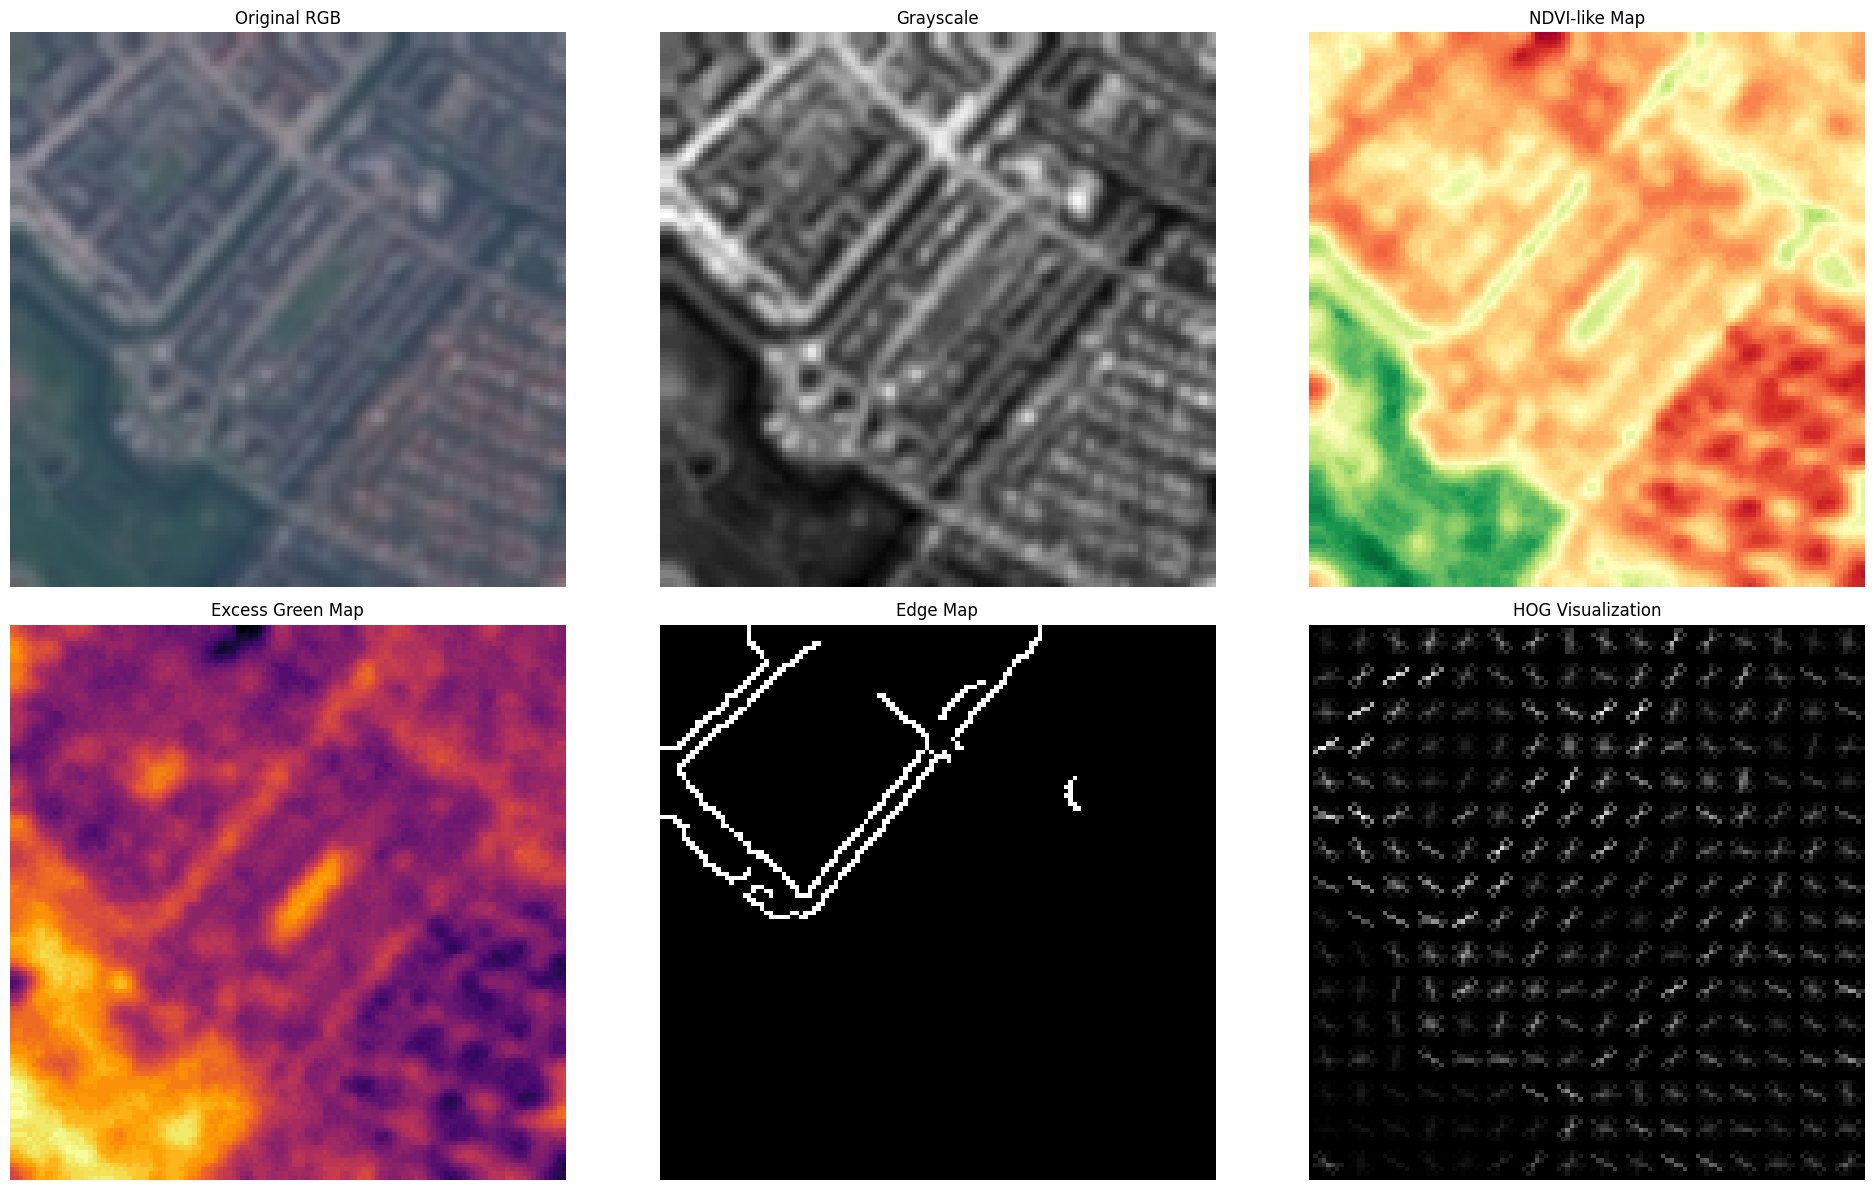

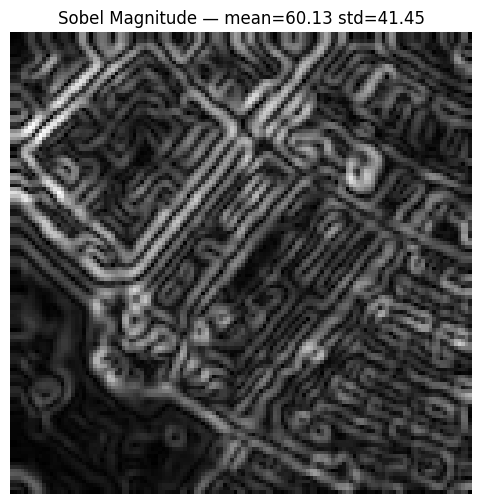

Sobel mean: 60.1283, Sobel std: 41.4544


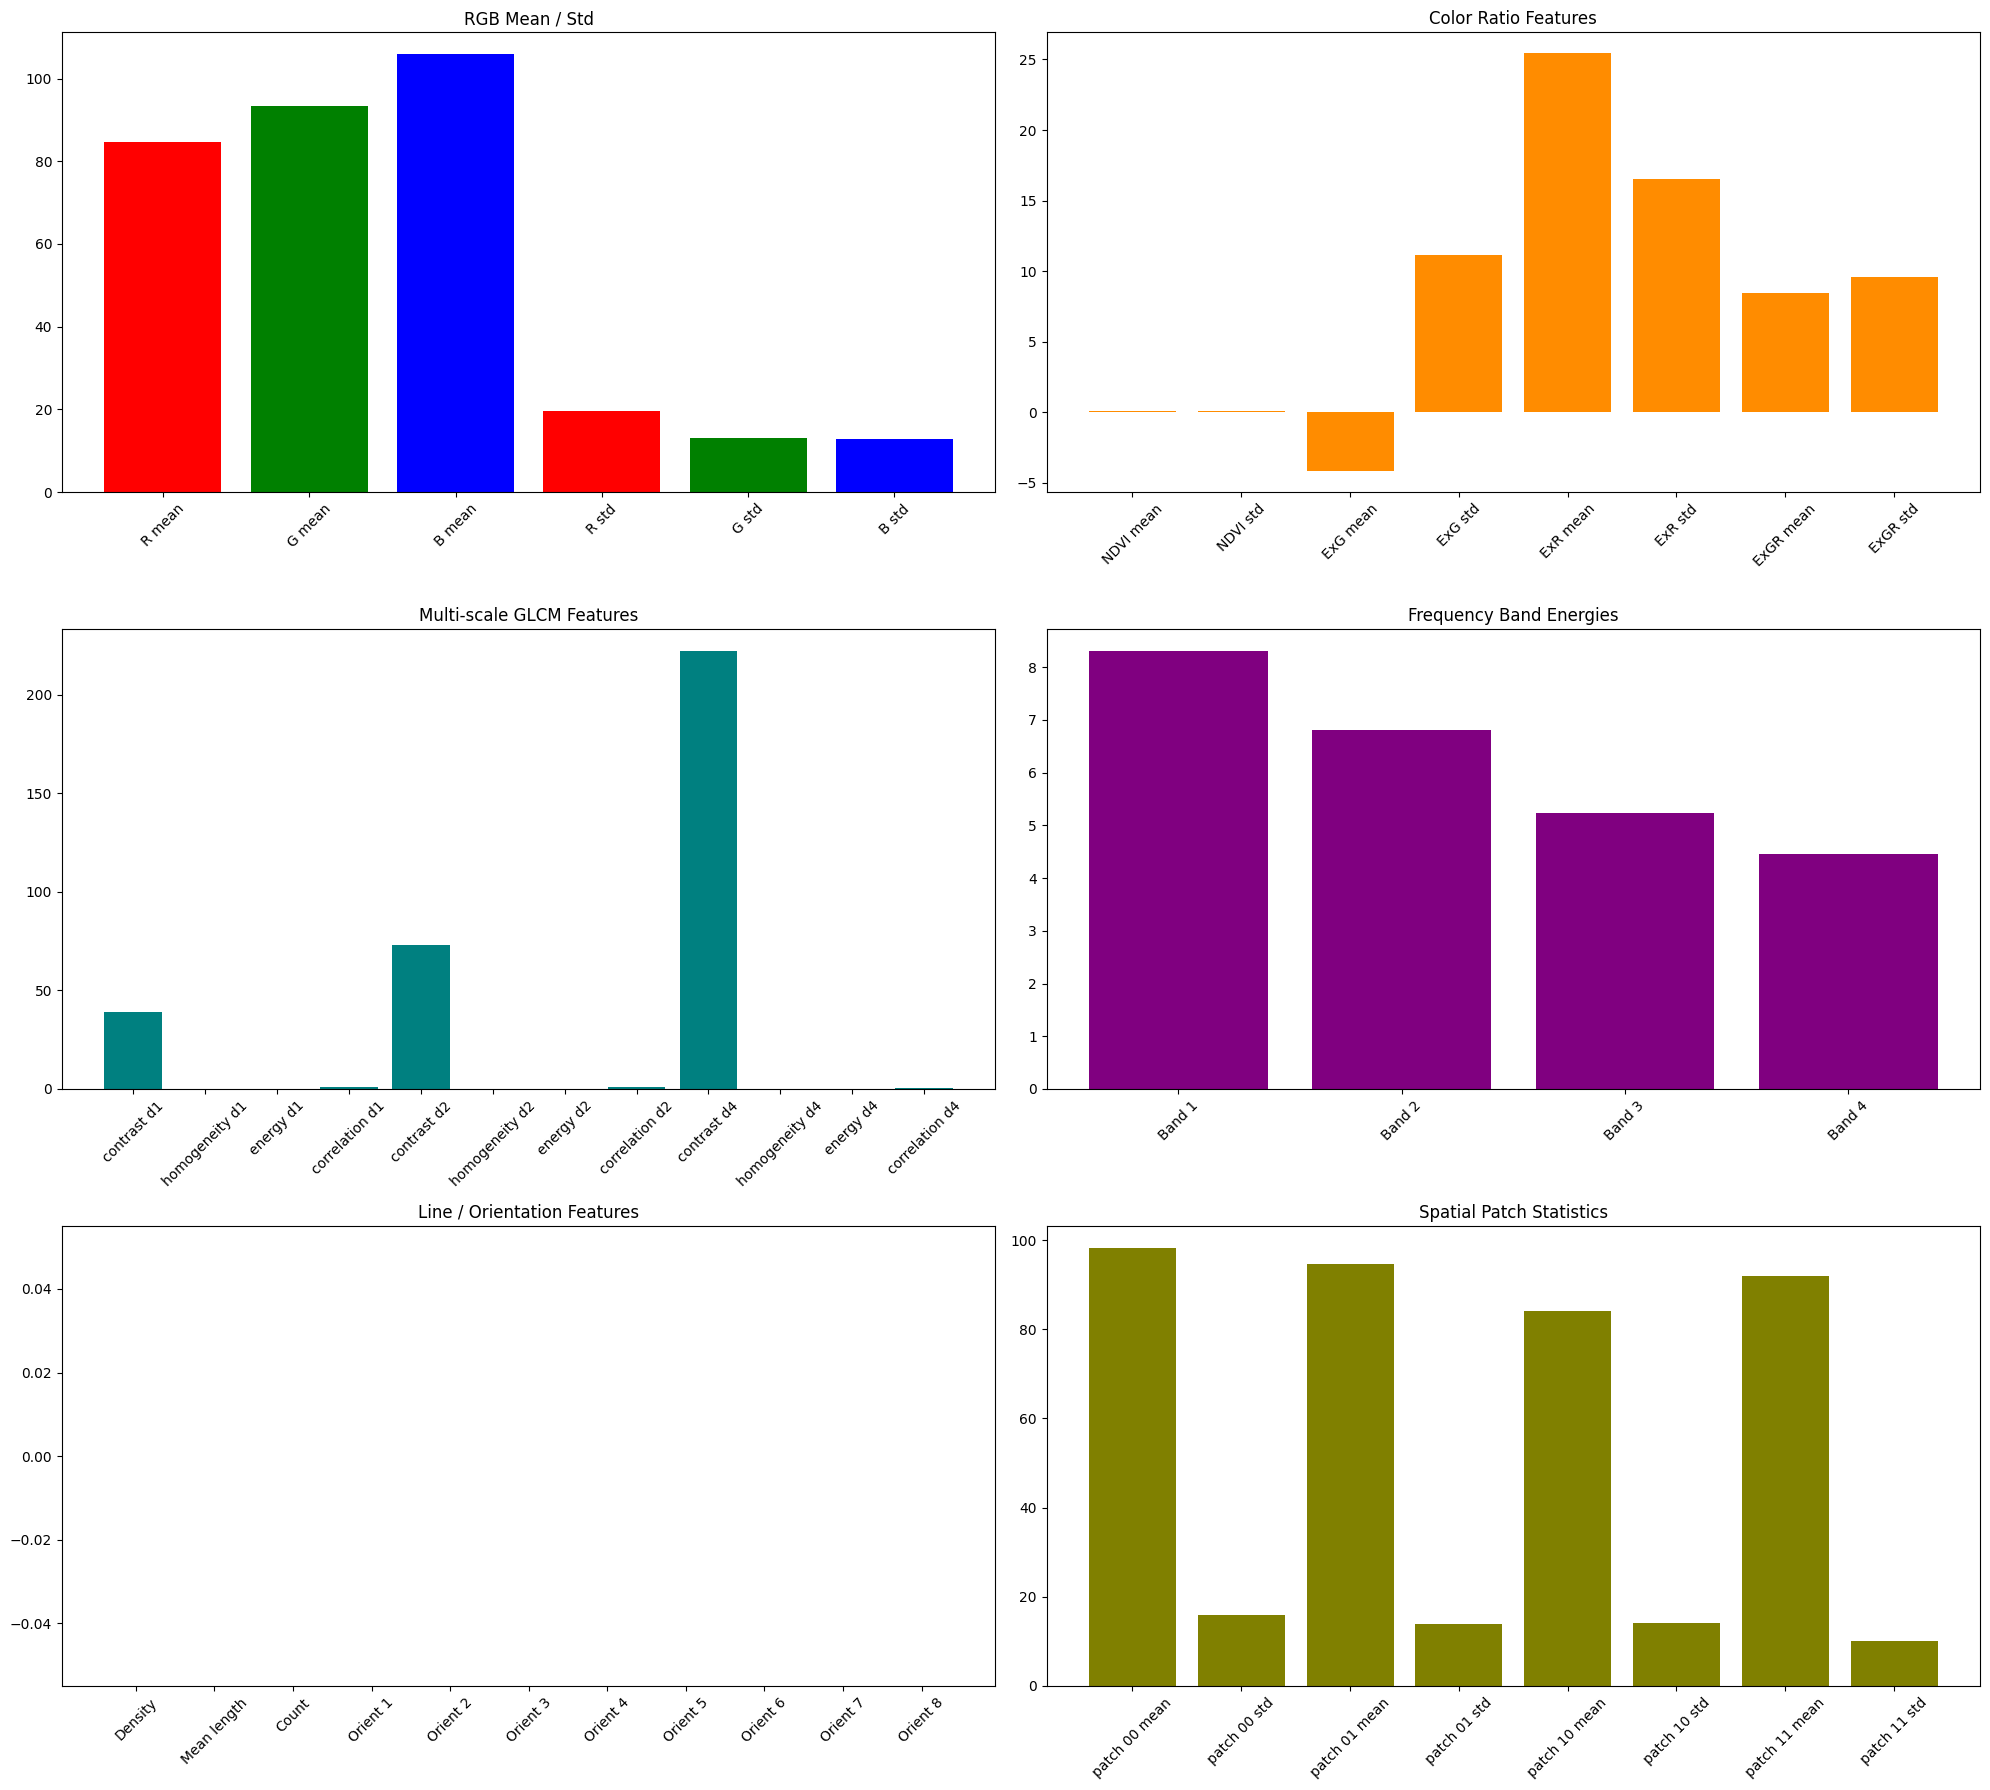

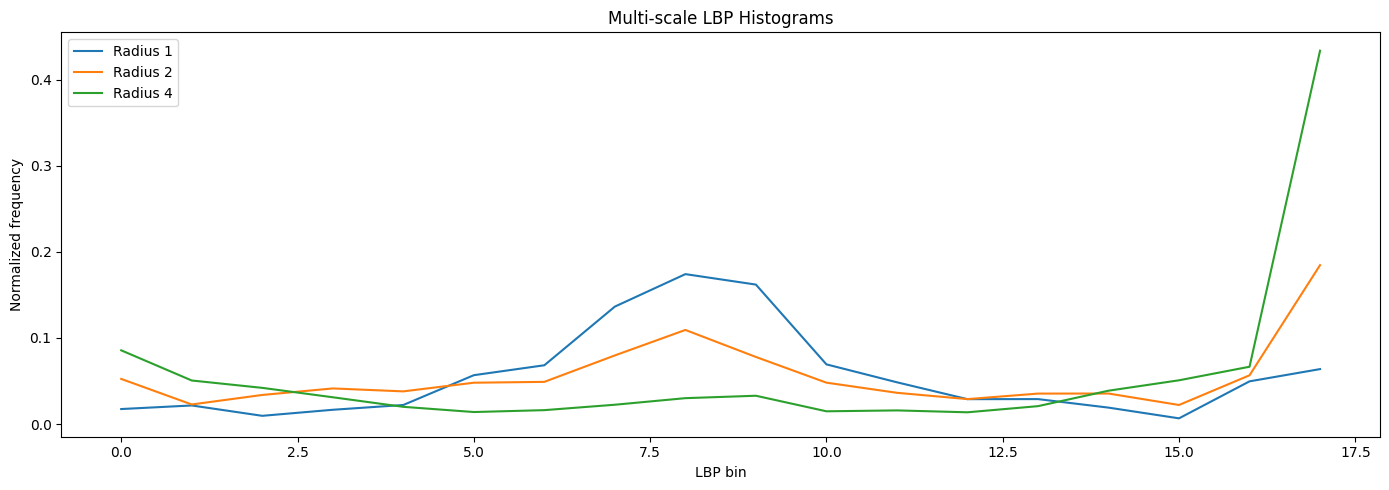

2026-05-23 14:30:27,893 [WARNING] No external image found.
2026-05-23 14:30:27,904 [INFO] main completed in 107.90 sec


Edge density: 0.16961669921875
Total feature groups visualized: Pixel, Ratio, GLCM, LBP, Frequency, Line, Spatial, Edge


In [7]:
@timer
def main():
    X, y = load_dataset()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=Config.TEST_SIZE,
        random_state=Config.RANDOM_STATE,
        stratify=y
    )

    logger.info(f"Train Shape: {X_train.shape}")
    logger.info(f"Test Shape: {X_test.shape}")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    models = train_models(X_train, y_train)

    for name, model in models.items():
        evaluate_model(model, X_test, y_test, name)

    sample_image = os.path.join(
        Config.DATASET_PATH,
        "Residential",
        os.listdir(os.path.join(Config.DATASET_PATH, "Residential"))[0]
    )

    visualize_features(sample_image)

    external_image = "external_test.jpg"
    if os.path.exists(external_image):
        best_model = models["SVM"]
        predict_external_image(best_model, scaler, external_image)
    else:
        logger.warning("No external image found.")



if __name__ == "__main__":
    main()


## Visualize fetaures

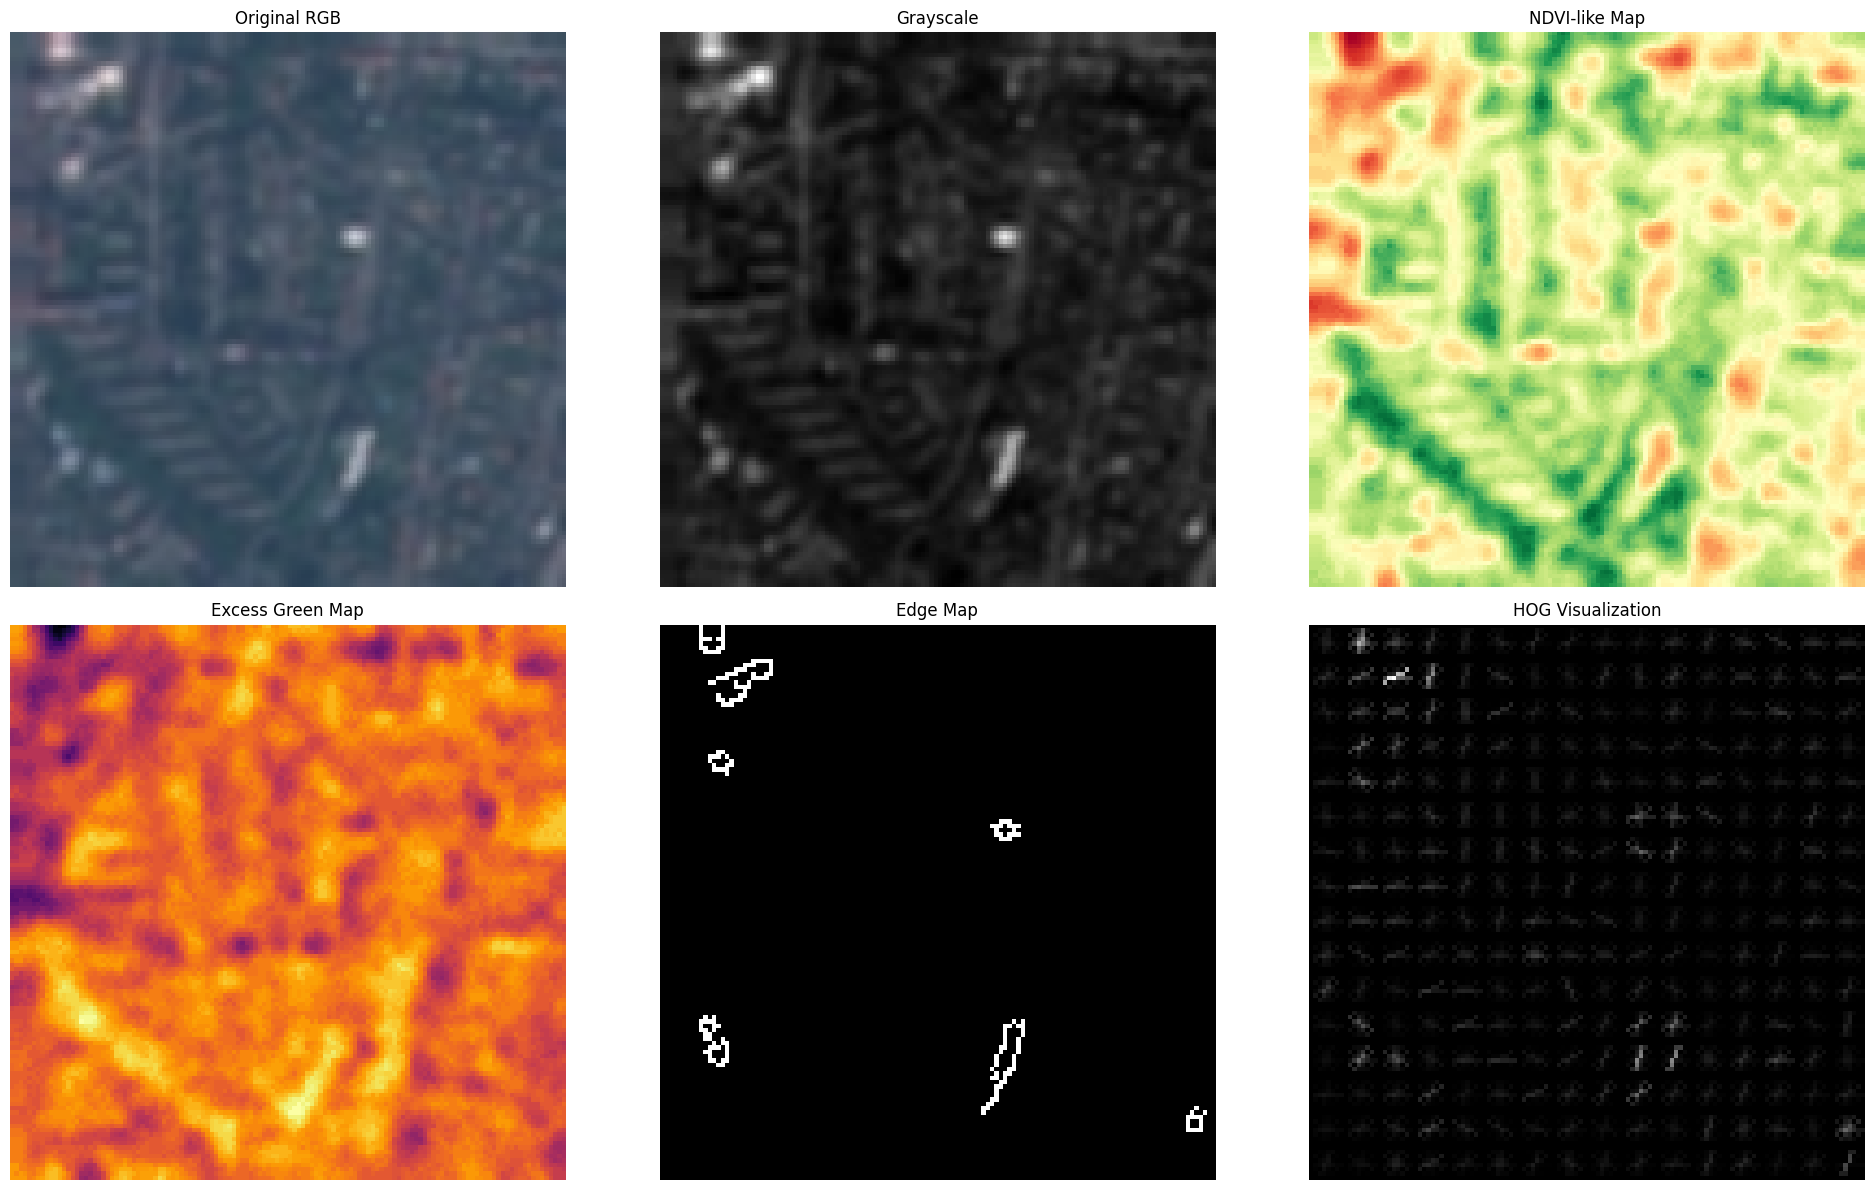

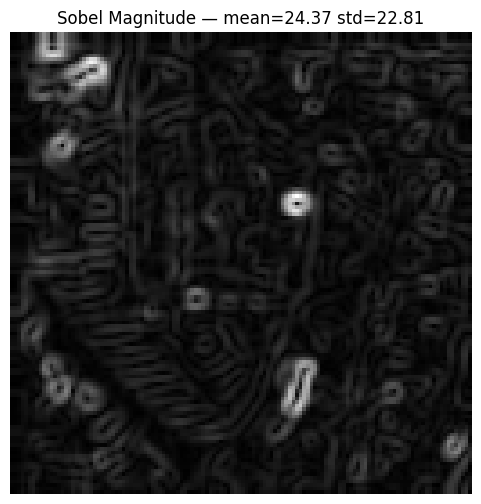

Sobel mean: 24.3677, Sobel std: 22.8143


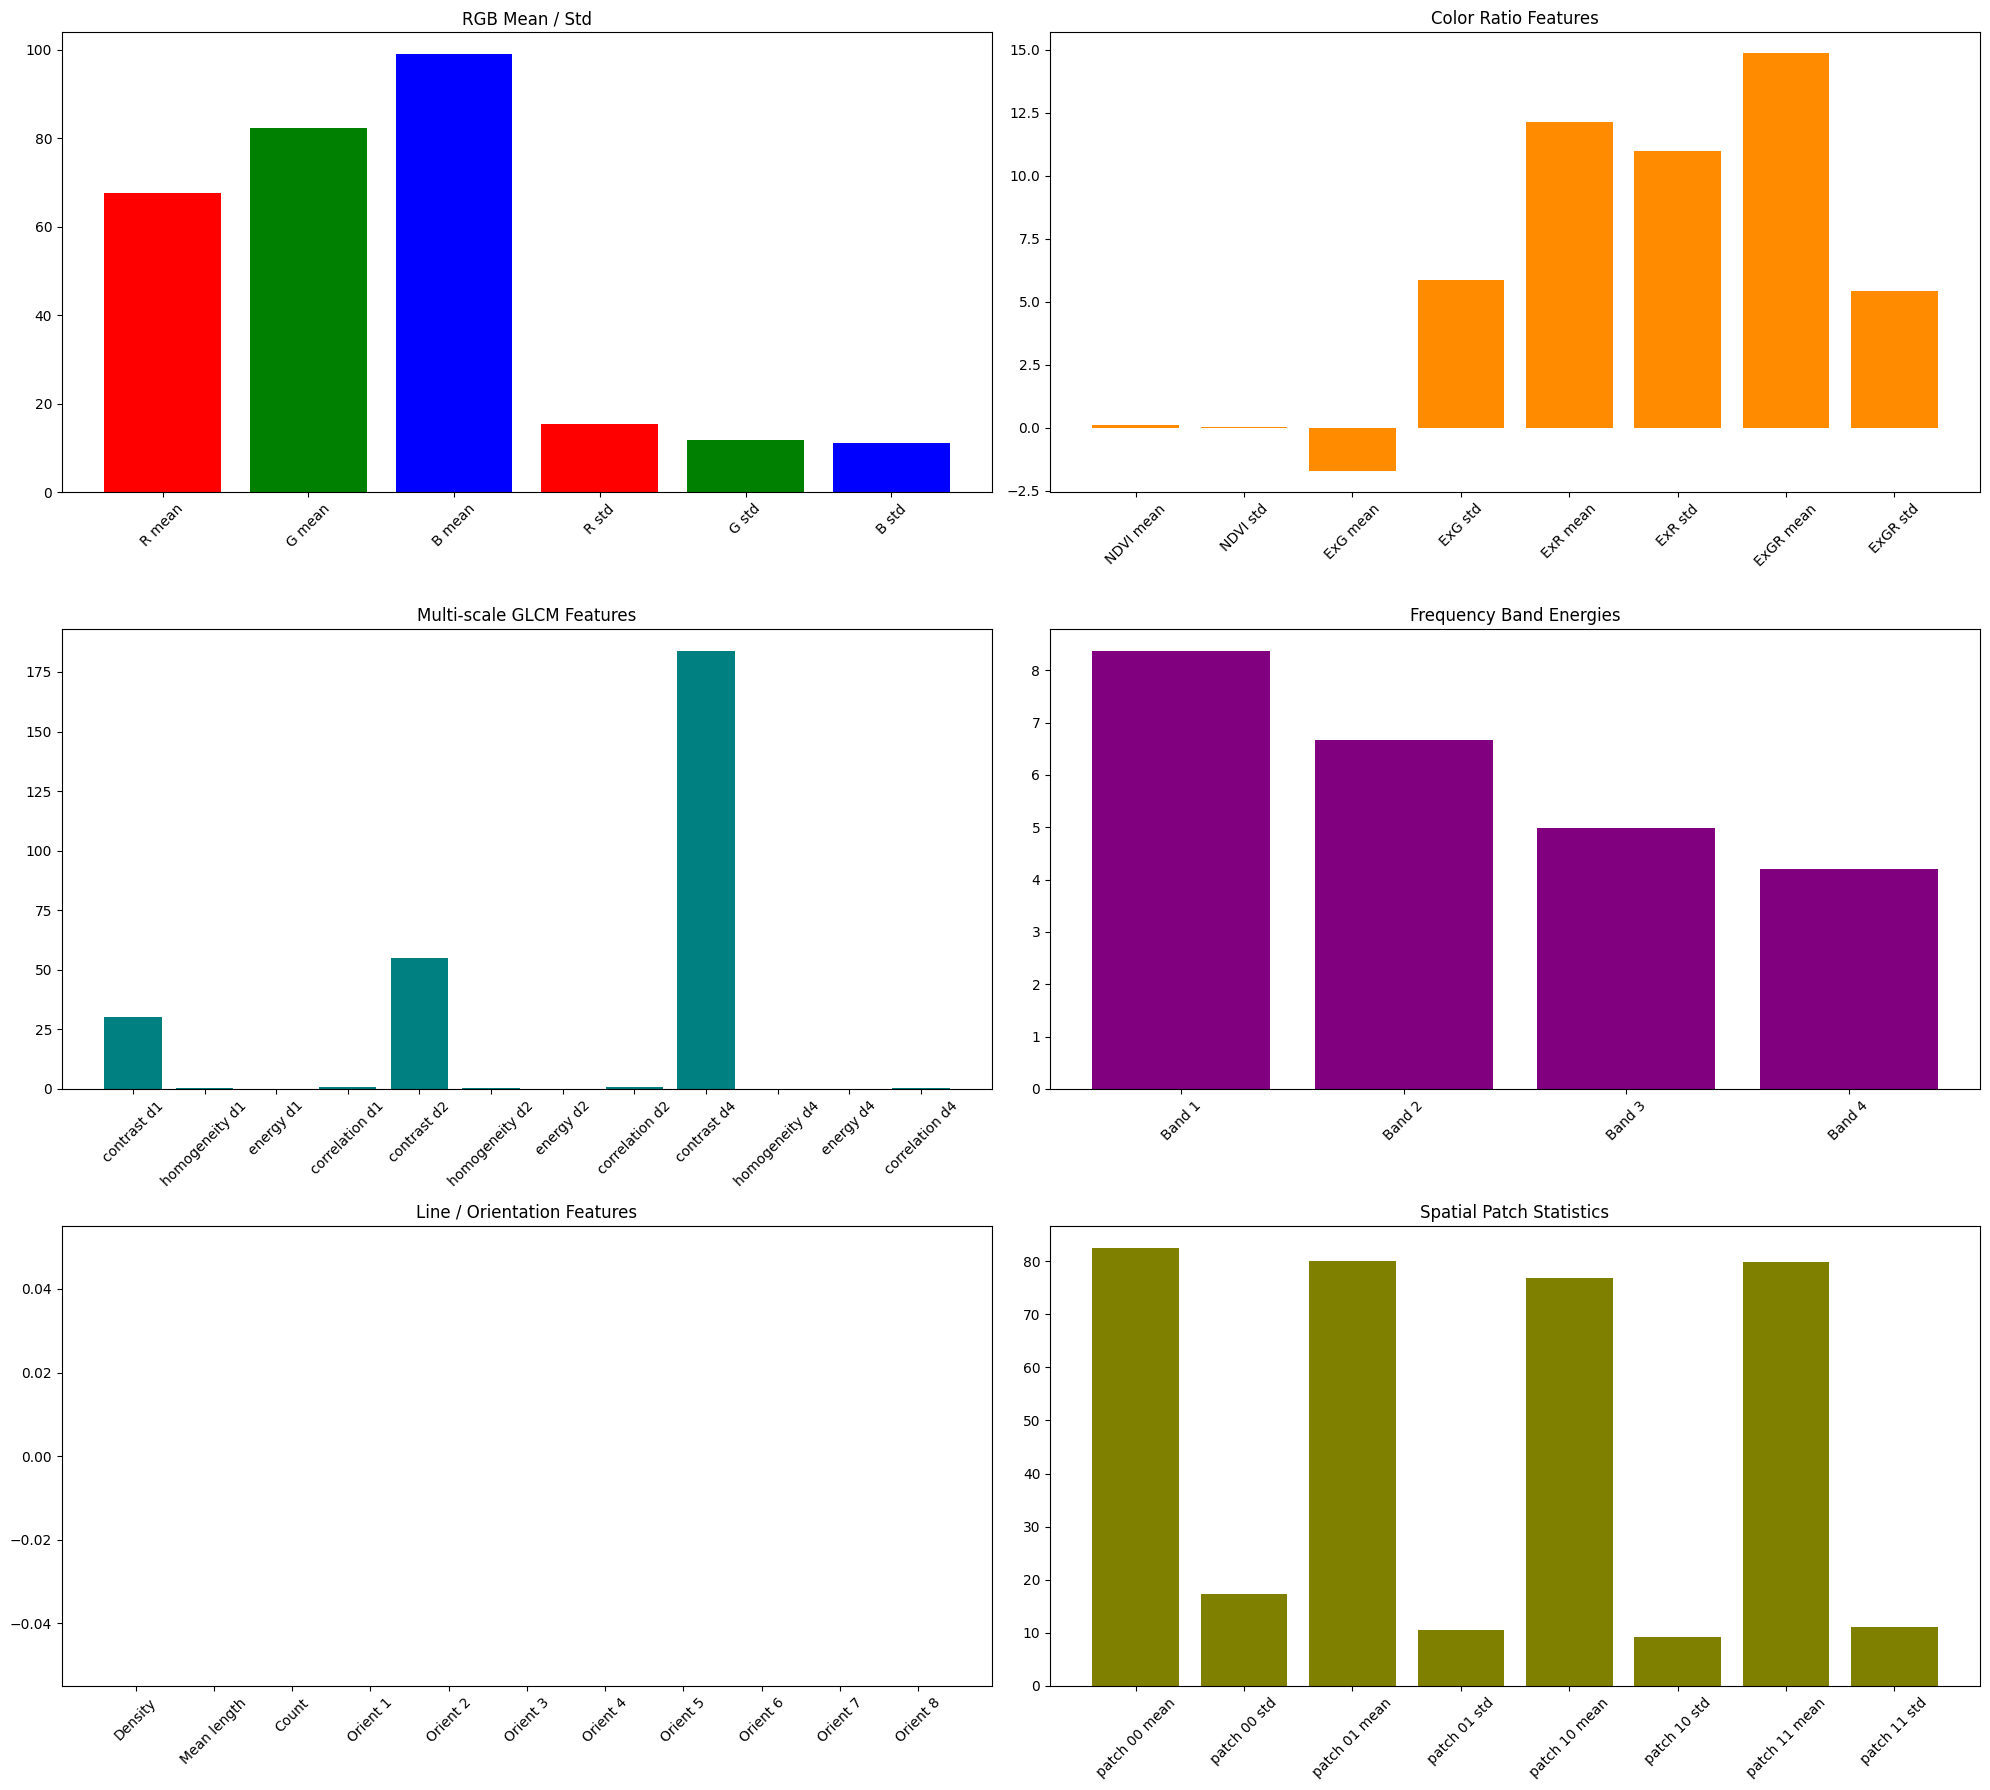

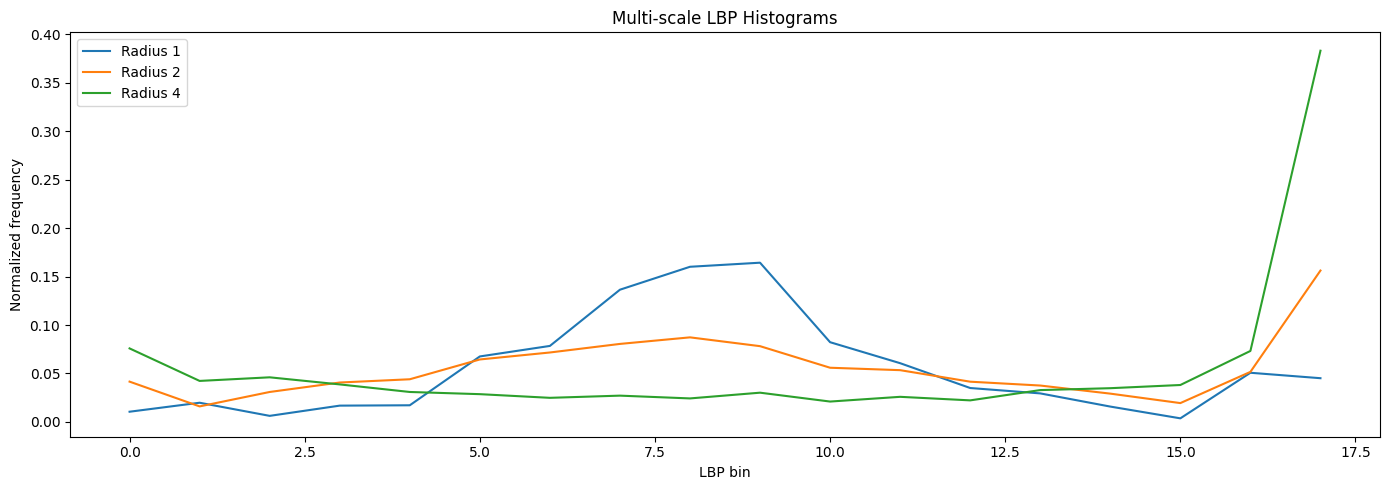

Edge density: 0.126708984375
Total feature groups visualized: Pixel, Ratio, GLCM, LBP, Frequency, Line, Spatial, Edge


In [8]:
sample_image = os.path.join(
        Config.DATASET_PATH,
        "Residential",
        os.listdir(os.path.join(Config.DATASET_PATH, "Residential"))[50]
    )

visualize_features(sample_image)

Configurable parameters in the notebook

#### 1. Config.IMAGE_SIZE

- Significance: controls the resolution of every image before feature extraction.
- Increase: preserves more detail, can improve feature quality, but increases compute time and memory.
- Decrease: makes processing faster and features smaller, but may lose fine texture and edge detail.

#### 2. Config.MAX_IMAGES_PER_CLASS

- Significance: limits how many images are loaded for each class.
- Increase: more training data → typically better model generalization, but slower loading/training.
- Decrease: faster experiments, but models may underfit and accuracy can drop.

#### 3. Config.TEST_SIZE

- Significance: fraction of data reserved for evaluation.
- Increase: more reliable test evaluation, but less training data.
- Decrease: more training data, but evaluation becomes less robust and may overestimate performance.

#### 4. Config.RANDOM_STATE

- Significance: seed for reproducibility of splits and model behavior.
- Increase/decrease: does not change model behavior in expectation, only changes which exact samples are assigned to train/test. It is for reproducibility, not performance tuning.
Texture and gradient feature parameters

#### 5. Config.LBP_POINTS

- Used by Local Binary Pattern.
- Significance: number of neighbors around each pixel.
- Increase: captures more angular detail, gives richer texture description, but longer histogram and more sensitivity to noise.
- Decrease: simpler texture description, less detail, faster and often more robust for noisy images.

#### 6. Config.LBP_RADIUS

- Used by Local Binary Pattern.
- Significance: distance from center pixel to neighbors.
- Increase: captures broader texture patterns over larger neighborhoods.
- Decrease: captures only very local micro-texture.

#### 7. Config.LBP_RADII

- Used by multi-scale LBP extraction.
- Significance: defines multiple radii for texture capture at different scales.
- Increase count or values: more multi-scale texture detail, larger feature vector, more compute.
- Decrease: simpler and more compact texture representation.

#### 8. Config.HOG_ORIENTATIONS

- Used by HOG.
- Significance: number of orientation bins for gradient directions.
- Increase: finer edge direction resolution, more discriminative gradient features, but larger feature vector.
- Decrease: coarser orientation encoding, less detail but smaller feature size.

#### 9. Config.HOG_PIXELS_PER_CELL

- Used by HOG.
- Significance: size of the basic spatial cell.
- Increase: each cell covers more pixels → coarser spatial resolution, fewer features, smoother gradients.
- Decrease: finer spatial resolution, more features, potentially more sensitive to noise.

#### 10. Config.HOG_CELLS_PER_BLOCK

- Used by HOG.
- Significance: block normalization region.
- Increase: more context in each normalized block, larger feature vector, more stable descriptor.
- Decrease: smaller normalization area, less context, potentially less stable but smaller descriptor.
- Co-occurrence and directional texture

#### 11. Config.GLCM_DISTANCES

- Used by multi-scale GLCM.
- Significance: distances between paired pixels for texture co-occurrence.
- Increase values / more distances: captures texture at larger scales and more scales, but longer feature vector and more compute.
- Decrease: focuses on very local relationships.

#### 12. Config.GLCM_ANGLES

- Used by GLCM.
- Significance: directions in which pixel pairs are compared.
- Increase angles: captures more directional texture variation, more robust to orientation.
- Decrease angles: faster and lower-dimensional, but may miss directional differences.
Spatial, line, and frequency parameters

#### 13. Config.SPATIAL_GRID

- Used in extract_spatial_features.
- Significance: divides the image into patches and computes local mean/std.
- Increase grid size: better capture of spatial structure, but more features and possible overfitting.
- Decrease grid size: more global statistics, fewer features, less spatial detail.

#### 14. Config.LINE_ORIENTATION_BINS

- Used in extract_line_features.
- Significance: number of bins for the line angle histogram.
- Increase: more precise orientation distribution of lines, but sparse representation.
- Decrease: coarser orientation summary, simpler and more stable.

#### 15. Config.DFT_BANDS

- Used in extract_frequency_features.
- Significance: number of radial frequency bands in Fourier magnitude.
- Increase: finer frequency resolution, more features, more sensitivity to texture frequency.
- Decrease: coarser frequency summary, smaller feature vector.
- Additional implicit tuning knobs in feature code
These are not in Config but affect feature behavior:

#### Extra
- Color histogram bins: currently 32 per channel. Increase → finer color detail, larger vector.
- Sobel kernel ksize=3: larger kernels smooth more and detect broader gradients; smaller kernels capture finer edges.
- Canny thresholds 100, 200: lower thresholds detect more edges/noise; higher thresholds keep only strong edges.
- Hough line thresholds: control line detection sensitivity and minimum line length.

- Practical guidance:
> Increase parameters when you want more descriptive power and have enough compute/data.
> Decrease parameters when the model is too slow, overfits, or the dataset is noisy.

- The main tradeoff is always:
> more features/detail → better potential discrimination but higher cost and risk of overfitting
less detail → faster, more stable, but potentially less accurate